# Proyecto Integrador: Diagnóstico Data-Driven del Registro de Nacimientos en Bolivia (2009-2015)

---

## Información del Curso

| Campo | Detalle |
|-------|---------|
| **Programa** | Diplomado en Big Data, Analytics y Business Intelligence v1 |
| **Módulo** | Módulo 1: Transformación Digital y Fundamentos de Big Data |
| **Docente** | Lic. Marcelo Pinto Macedo |
| **Estudiante** | Lic. Ilian Joseph Felipez Vaca |

## 1. Contexto del dataset

### 1.1 Origen del dataset

El dataset fue obtenido del **Portal de Datos Abiertos de Bolivia** ([datos.gob.bo](https://datos.gob.bo)), específicamente del conjunto denominado *"Cantidad de nacimientos registrados, 2009-2015"*, disponible en el siguiente enlace: [https://datos.gob.bo/dataset/cantidad-de-nacimientos-registrados-2009-20152](https://datos.gob.bo/dataset/cantidad-de-nacimientos-registrados-2009-20152).

### 1.2 Institución o plataforma que lo publica

La información es publicada por el **Ministerio de Salud del Estado Plurinacional de Bolivia**, a través del **Sistema Nacional de Información en Salud (SNIS)**. Los archivos originales fueron descargados directamente de la plataforma en formato CSV para su posterior procesamiento y análisis.

### 1.3 Problema o fenómeno que representa

El dataset documenta el fenómeno de los **nacimientos ocurridos en Bolivia entre 2009 y 2015**, desagregando entre nacidos vivos y nacidos muertos (defunciones fetales). Además, incorpora información sobre la atención recibida por personal de salud, lo que permite evaluar si los partos fueron asistidos por profesionales médicos o si ocurrieron fuera del sistema institucional. El período de cobertura abarca 7 años, con registros a nivel municipal y departamental.

### 1.4 Relevancia del análisis

El análisis de estos datos es relevante porque:
- Permite realizar el **seguimiento institucional de los hechos vitales**, proporcionando una base objetiva para la planificación de servicios de salud, educación y programas sociales.
- Facilita la **evaluación de la capacidad de respuesta del personal de salud en cada municipio**, identificando brechas de cobertura y zonas con acceso limitado a atención profesional.
- Contribuye a la **detección de riesgos en salud neonatal**, al analizar las tasas de mortalidad fetal en relación con la atención recibida.
- Provee **evidencia para la toma de decisiones estratégicas**, orientando la asignación de recursos, el despliegue de brigadas móviles y el fortalecimiento de la infraestructura sanitaria en territorios prioritarios.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("="*60)
print("CARGA DE DATOS - REGISTRO DE NACIMIENTOS BOLIVIA 2009-2015")
print("="*60)

# Base URL de GitHub (raw)
base_url = "https://raw.githubusercontent.com/ElTioCrack/BigData-BI-Diploma/main/homeworks/Tarea%204/data_nacimientos/"

# Nombres de los archivos
archivos = [
    "minsalud_registro_nacidos_2009.csv",
    "minsalud_registro_nacidos_2010.csv",
    "minsalud_registro_nacidos_2011.csv",
    "minsalud_registro_nacidos_2012.csv",
    "minsalud_registro_nacidos_2013.csv",
    "minsalud_registro_nacidos_2014.csv",
    "minsalud_registro_nacidos_2015.csv"
]

# Diccionario para almacenar los dataframes por año
data_por_anio = {}

# Cargar cada archivo con manejo de codificaciones
for archivo in archivos:
    url = base_url + archivo
    anio = archivo.split('_')[-1].replace('.csv', '')

    try:
        df = pd.read_csv(url, encoding='utf-8')
        df['anio'] = anio
        data_por_anio[anio] = df
        print(f"[OK] Cargado: {archivo} (utf-8) - {len(df)} registros")
    except UnicodeDecodeError:
        try:
            df = pd.read_csv(url, encoding='latin-1')
            df['anio'] = anio
            data_por_anio[anio] = df
            print(f"[OK] Cargado: {archivo} (latin-1) - {len(df)} registros")
        except Exception as e:
            print(f"[ERROR] Error al cargar {archivo}: {e}")
    except Exception as e:
        print(f"[ERROR] Error al cargar {archivo}: {e}")

print("-"*60)
print(f"Años cargados: {list(data_por_anio.keys())}")
print("="*60)

CARGA DE DATOS - REGISTRO DE NACIMIENTOS BOLIVIA 2009-2015
[OK] Cargado: minsalud_registro_nacidos_2009.csv (latin-1) - 324 registros
[OK] Cargado: minsalud_registro_nacidos_2010.csv (utf-8) - 334 registros
[OK] Cargado: minsalud_registro_nacidos_2011.csv (utf-8) - 333 registros
[OK] Cargado: minsalud_registro_nacidos_2012.csv (utf-8) - 339 registros
[OK] Cargado: minsalud_registro_nacidos_2013.csv (utf-8) - 339 registros
[OK] Cargado: minsalud_registro_nacidos_2014.csv (utf-8) - 336 registros
[OK] Cargado: minsalud_registro_nacidos_2015.csv (utf-8) - 337 registros
------------------------------------------------------------
Años cargados: ['2009', '2010', '2011', '2012', '2013', '2014', '2015']


## 2. Descripción de la estructura de los datos

### 2.1 Estructura original

Los archivos originales descargados del Portal de Datos Abiertos de Bolivia para el período 2009-2015 contienen las siguientes variables:

| Variable | Tipo | Significado |
|----------|------|-------------|
| **id** | Numérica | Identificador único del registro. |
| **cod_dep** | Numérica | Código numérico del departamento. |
| **departamento** | Categórica | Nombre del departamento. |
| **cod_mun** | Numérica | Código numérico del municipio. |
| **municipio** | Categórica | Nombre del municipio. |
| **nacidos_vivos** | Numérica | Conteo de nacidos vivos registrados. |
| **nacidos_vivos_atendidos_por_personal_de_salud** | Numérica | Número de nacidos vivos atendidos por personal de salud. |
| **nacidos_muertos** | Numérica | Conteo de nacidos muertos (mortinatos). |
| **nacidos_muertos_atendidos_por_personal_de_salud** | Numérica | Número de nacidos muertos atendidos por personal de salud. |
| **total_general** | Numérica | Suma total de nacimientos (vivos + muertos). |

**Nota:** El archivo correspondiente al año 2015 incluye una columna adicional denominada `nacidos_muertos_atendidos_por_partera`, la cual no está presente en los archivos de los años anteriores. Esta columna fue excluida del análisis por no contar con datos comparables en toda la serie temporal.


In [61]:
# ============================================================================
# LIMPIEZA Y ESTANDARIZACIÓN DE DATOS
# ============================================================================

print("="*60)
print("LIMPIEZA Y ESTANDARIZACIÓN DE DATOS")
print("="*60)

def normalizar_texto(texto):
    if not isinstance(texto, str) or texto.lower() in ['nan', 'none', '']:
        return None

    # Corrección de encodings rotos del origen CSV
    texto = texto.replace('Ã±', 'Ñ').replace('Ã‘', 'Ñ').replace('Ã¡', 'Á')\
                 .replace('Ã©', 'É').replace('Ã­', 'Í').replace('Ã³', 'Ó').replace('Ãº', 'Ú')

    # Normalización de caracteres y limpieza de espacios
    texto = unicodedata.normalize('NFKC', texto)
    return " ".join(texto.split()).upper()

dataframes_limpios = []

print("\n[PASO 1] Procesando archivos por año")
print("-"*40)

for anio, df in data_por_anio.items():
    print(f"\n>> Año {anio}")

    # 1.1 Selección de columnas
    print("   [1.1] Seleccionando columnas estándar...")
    cols = [c for c in columnas_estandar if c in df.columns]
    df = df[cols].copy()

    # 1.2 Limpieza de texto
    print("   [1.2] Limpiando campos de texto (Normalización)...")
    for col in ['departamento', 'municipio']:
        if col in df.columns:
            df[col] = df[col].apply(normalizar_texto)

    # 1.3 Conversión numérica
    print("   [1.3] Convirtiendo columnas numéricas...")
    cols_num = ['id', 'cod_dep', 'nacidos_vivos', 'nacidos_vivos_atendidos_por_personal_de_salud',
                'nacidos_muertos', 'nacidos_muertos_atendidos_por_personal_de_salud', 'total_general']
    for col in cols_num:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

    # 1.4 Estandarización de códigos
    print("   [1.5] Estandarizando códigos municipales...")
    if 'cod_mun' in df.columns:
        df['cod_mun'] = df['cod_mun'].astype(str).str.split('.').str[0].str.zfill(5)

    # 1.5 Validación de consistencia
    print("   [1.6] Validando consistencia (Reglas de Negocio)...")
    df['total_general'] = df['nacidos_vivos'] + df['nacidos_muertos']
    df['nacidos_vivos_atendidos_por_personal_de_salud'] = np.where(
        df['nacidos_vivos_atendidos_por_personal_de_salud'] > df['nacidos_vivos'],
        df['nacidos_vivos'],
        df['nacidos_vivos_atendidos_por_personal_de_salud']
    )

    # 1.6 Depuración
    print("   [1.7] Eliminando registros inválidos y duplicados...")
    df = df.dropna(subset=['id', 'departamento', 'municipio'])
    df = df.drop_duplicates()

    df['anio'] = anio
    dataframes_limpios.append(df)
    print(f"   [OK] {anio}: {len(df)} registros listos.")

# ----------------------------------------------------------------------------
# CONSOLIDACIÓN FINAL
# ----------------------------------------------------------------------------

print("\n[PASO 2] Consolidando dataset maestro...")
df_total = pd.concat(dataframes_limpios, ignore_index=True)

print("[PASO 3] Aplicando ordenamiento jerárquico...")
df_total = df_total.sort_values(['anio', 'cod_dep', 'cod_mun']).reset_index(drop=True)

print("\n[PASO 4] Validación final del dataset")
print("-" * 40)
print(f"Registros Totales: {len(df_total)}")
print(f"Departamentos:     {sorted(df_total['departamento'].unique())}")
print(f"Nulos restantes:   {df_total.isnull().sum().sum()}")

print("\n" + "="*60)
print("PROCESO DE LIMPIEZA COMPLETADO")
print("="*60)

LIMPIEZA Y ESTANDARIZACIÓN DE DATOS

[PASO 1] Procesando archivos por año
----------------------------------------

>> Año 2009
   [1.1] Seleccionando columnas estándar...
   [1.2] Limpiando campos de texto (Normalización)...
   [1.3] Convirtiendo columnas numéricas...
   [1.5] Estandarizando códigos municipales...
   [1.6] Validando consistencia (Reglas de Negocio)...
   [1.7] Eliminando registros inválidos y duplicados...
   [OK] 2009: 324 registros listos.

>> Año 2010
   [1.1] Seleccionando columnas estándar...
   [1.2] Limpiando campos de texto (Normalización)...
   [1.3] Convirtiendo columnas numéricas...
   [1.5] Estandarizando códigos municipales...
   [1.6] Validando consistencia (Reglas de Negocio)...
   [1.7] Eliminando registros inválidos y duplicados...
   [OK] 2010: 334 registros listos.

>> Año 2011
   [1.1] Seleccionando columnas estándar...
   [1.2] Limpiando campos de texto (Normalización)...
   [1.3] Convirtiendo columnas numéricas...
   [1.5] Estandarizando códigos 

### 2.2 Estructura luego del proceso de limpieza y estandarización

Luego de aplicar los procesos de consolidación, limpieza y estandarización, se obtuvo un dataset unificado con las siguientes variables:

| Variable | Tipo | Significado |
|----------|------|-------------|
| **id** | Numérica | Identificador único del registro a nivel municipal. |
| **cod_dep** | Numérica | Código institucional asignado al departamento. |
| **departamento** | Categórica | Nombre del departamento estandarizado (ejemplo: CHUQUISACA, LA PAZ, SANTA CRUZ). |
| **cod_mun** | Categórica | Código único del municipio, estandarizado a 5 dígitos. |
| **municipio** | Categórica | Nombre del municipio corregido (ejemplo: SUCRE, EL ALTO, COCHABAMBA). |
| **nacidos_vivos** | Numérica | Conteo total de nacimientos ocurridos con vida en el municipio. |
| **nacidos_vivos_atendidos_por_personal_de_salud** | Numérica | Número de nacidos vivos atendidos por personal médico o de salud calificado. |
| **nacidos_muertos** | Numérica | Conteo de nacidos muertos (mortinatos o defunciones fetales) registrados. |
| **nacidos_muertos_atendidos_por_personal_de_salud** | Numérica | Número de nacidos muertos cuya atención fue brindada por personal de salud. |
| **total_general** | Numérica | Sumatoria total de nacimientos en el municipio, equivalente a nacidos vivos más nacidos muertos. |
| **anio** | Categórica | Año de registro del dato, comprendido entre 2009 y 2015. |

## 3. Identificación de datos relevantes

**Variables relevantes:**

| Variable | Tipo | Justificación |
|----------|------|----------------|
| **departamento** | Categórica | Permite identificar las regiones con mayor carga de natalidad y priorizar intervenciones territoriales. |
| **municipio** | Categórica | Posibilita un análisis desagregado a nivel local, esencial para detectar zonas rurales o periurbanas con necesidades específicas en salud materno-infantil. |
| **nacidos_vivos** | Numérica | Constituye la base fundamental para estimar el crecimiento poblacional y proyectar la demanda de servicios de salud, educación y otros programas sociales. |
| **nacidos_muertos** | Numérica | Actúa como indicador crítico de alerta en salud neonatal. Su análisis permite detectar patrones preocupantes y evaluar la calidad de la atención prenatal y del parto. |
| **nacidos_vivos_atendidos_por_personal_de_salud** | Numérica | Mide la cobertura real del sistema sanitario. Una alta proporción indica acceso efectivo a servicios de salud calificados durante el parto. |
| **nacidos_muertos_atendidos_por_personal_de_salud** | Numérica | Permite analizar si las defunciones fetales ocurrieron bajo supervisión médica o en contextos de ausencia de atención profesional, diferenciando entre fallas del sistema y condiciones no prevenibles. |
| **total_general** | Numérica | Funciona como variable de control para auditar la consistencia de los datos reportados, validando que cada registro municipal cumpla con la relación de integridad (vivos + muertos = total). |

**Variables descartadas:**

| Variable | Tipo | Motivo de exclusión |
|----------|------|---------------------|
| **id** | Numérica | Su función es meramente administrativa y no aporta valor al análisis estratégico. |
| **cod_dep** | Numérica | Aunque útil para joins con otros datasets, el análisis se centra en los nombres textuales por su claridad interpretativa. |
| **cod_mun** | Numérica | Aunque útil para joins con otros datasets, el análisis se centra en los nombres textuales por su claridad interpretativa. |
| **nacidos_muertos_atendidos_por_partera** | Numérica | Solo presente en el archivo 2015 y con alta tasa de valores nulos, lo que impide un análisis consistente a lo largo de la serie temporal. |

## 4. Análisis exploratorio de datos

### 4.1 Tendencia de nacidos vivos (2009-2015)

En esta sección se analiza la evolución cronológica de los nacidos vivos en Bolivia durante el septenio 2009-2015. El objetivo primordial es identificar patrones de comportamiento demográfico y estabilidad en la tasa de natalidad, proporcionando evidencia cuantitativa para la planificación estratégica de servicios de salud pública.

**Indicadores macro del período:**

* **Promedio anual de registros:** 189,578 nacimientos.
* **Valor mínimo observado:** 171,027 nacimientos (2009).
* **Valor máximo observado:** 205,539 nacimientos (2015).
* **Tasa de crecimiento acumulada:** +20.18% en el período de estudio.

**Análisis de la serie histórica:**

Los datos revelan una tendencia incremental sostenida. A diferencia de otros indicadores demográficos que presentan alta volatilidad, la serie 2009-2015 muestra un ascenso casi lineal. Este incremento acumulado del 20% señala una presión creciente sobre el sistema sanitario boliviano, demandando una optimización en la asignación de recursos hospitalarios y personal médico calificado en los nodos de recepción poblacional.

Gestión      Total Nacidos Vivos  Variación %    
--------------------------------------------------
2009                    171,027         0.00%
2010                    180,796         5.71%
2011                    190,525         5.38%
2012                    189,329        -0.63%
2013                    195,052         3.02%
2014                    194,777        -0.14%
2015                    205,539         5.53%
--------------------------------------------------
PROMEDIO                189,577


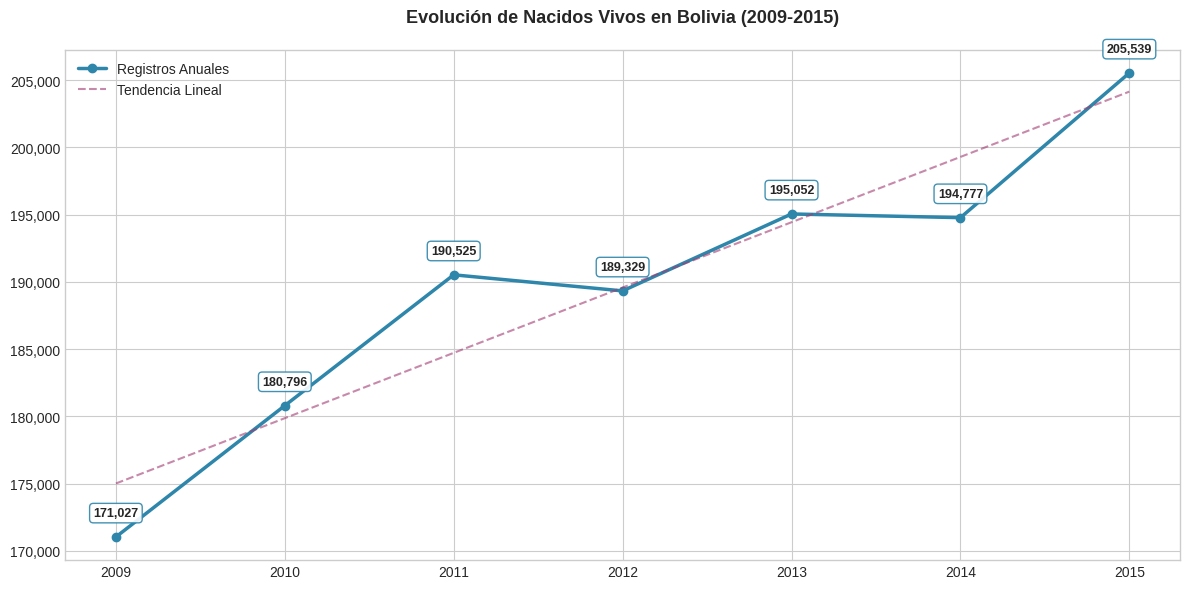


[CONCLUSIONES DEL ANÁLISIS DE TENDENCIA]
---------------------------------------------------------------------------
• Fiabilidad Estadística: Coeficiente de Variación del 5.83%.
  (Valores < 10% confirman una alta consistencia en el reporte nacional).
• Impacto Volumétrico: Incremento neto de 34,512 registros vivos.
  Este volumen representa una expansión del 20.2% en la demanda nominal.
• Perspectiva de BI: La tendencia ascendente no presenta quiebres estructurales,
  lo que permite proyectar una carga incremental constante para el sistema
  de salud pública en el corto y mediano plazo.
---------------------------------------------------------------------------


In [64]:
# ============================================================================
# 4.1.1 ANÁLISIS CUANTITATIVO DE NATALIDAD
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Agregación de datos
nacidos_por_anio = df_total.groupby('anio')['nacidos_vivos'].sum().reset_index()
nacidos_por_anio.columns = ['Año', 'Total']

# 1. TABLA DE VARIACIÓN INTERANUAL
print(f"{'Gestión':<12} {'Total Nacidos Vivos':<20} {'Variación %':<15}")
print("-" * 50)

for i, row in nacidos_por_anio.iterrows():
    var = 0.0 if i == 0 else ((row['Total'] - nacidos_por_anio.loc[i-1, 'Total']) / nacidos_por_anio.loc[i-1, 'Total']) * 100
    print(f"{row['Año']:<12} {int(row['Total']):>18,} {var:>12.2f}%")

print("-" * 50)
promedio = nacidos_por_anio['Total'].mean()
print(f"{'PROMEDIO':<12} {int(promedio):>18,}")

# 2. GENERACIÓN DE GRÁFICO DE TENDENCIA
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))

# Serie principal
ax.plot(nacidos_por_anio['Año'], nacidos_por_anio['Total'],
        marker='o', linewidth=2.5, color='#2E86AB', label='Registros Anuales')

# Etiquetas de datos
for i, row in nacidos_por_anio.iterrows():
    ax.annotate(f'{int(row["Total"]):,}', (row['Año'], row['Total']),
                textcoords="offset points", xytext=(0, 15), ha='center',
                fontsize=9, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc='white', ec='#2E86AB', alpha=0.9))

# Regresión Lineal
z = np.polyfit(range(len(nacidos_por_anio)), nacidos_por_anio['Total'], 1)
p = np.poly1d(z)
ax.plot(nacidos_por_anio['Año'], p(range(len(nacidos_por_anio))),
        linestyle='--', color='#A23B72', alpha=0.6, label='Tendencia Lineal')

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_title('Evolución de Nacidos Vivos en Bolivia (2009-2015)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# SÍNTESIS ANALÍTICA DE NATALIDAD
# ----------------------------------------------------------------------------

std_dev = nacidos_por_anio['Total'].std()
cv = (std_dev / promedio) * 100
crecimiento_abs = int(nacidos_por_anio['Total'].max() - nacidos_por_anio['Total'].min())

print("\n[CONCLUSIONES DEL ANÁLISIS DE TENDENCIA]")
print("-" * 75)
print(f"• Fiabilidad Estadística: Coeficiente de Variación del {cv:.2f}%.")
print(f"  (Valores < 10% confirman una alta consistencia en el reporte nacional).")
print(f"• Impacto Volumétrico: Incremento neto de {crecimiento_abs:,} registros vivos.")
print(f"  Este volumen representa una expansión del {crecimiento_total:.1f}% en la demanda nominal.")
print(f"• Perspectiva de BI: La tendencia ascendente no presenta quiebres estructurales,")
print(f"  lo que permite proyectar una carga incremental constante para el sistema")
print(f"  de salud pública en el corto y mediano plazo.")
print("-" * 75)

### 4.3 Análisis Geográfico: Cobertura Sanitaria vs. Mortalidad Fetal

En esta sección se evalúa la correlación entre la **cobertura de atención profesional** y la **tasa de mortalidad fetal** a nivel departamental. El objetivo es identificar asimetrías regionales y brechas críticas en la eficiencia del sistema de salud boliviano utilizando una **Matriz de Priorización de 4 Cuadrantes**.

**Definición de Cuadrantes:**

1.  **Zona Crítica (Rojo):** Baja Cobertura (< Promedio) + Alta Mortalidad (> Promedio). Requiere intervención inmediata en infraestructura y acceso.
2.  **Zona de Alerta de Calidad (Azul):** Alta Cobertura (> Promedio) + Alta Mortalidad (> Promedio). Sugiere que, aunque hay acceso al médico, la calidad de la atención o el estado de salud base es deficiente.
3.  **Zona de Subregistro Probable (Naranja):** Baja Cobertura (< Promedio) + Baja Mortalidad (< Promedio). Riesgo de datos incompletos o partos domiciliarios no registrados.
4.  **Zona Óptima (Verde):** Alta Cobertura (> Promedio) + Baja Mortalidad (< Promedio). Representa el estándar de eficiencia operativa deseado.

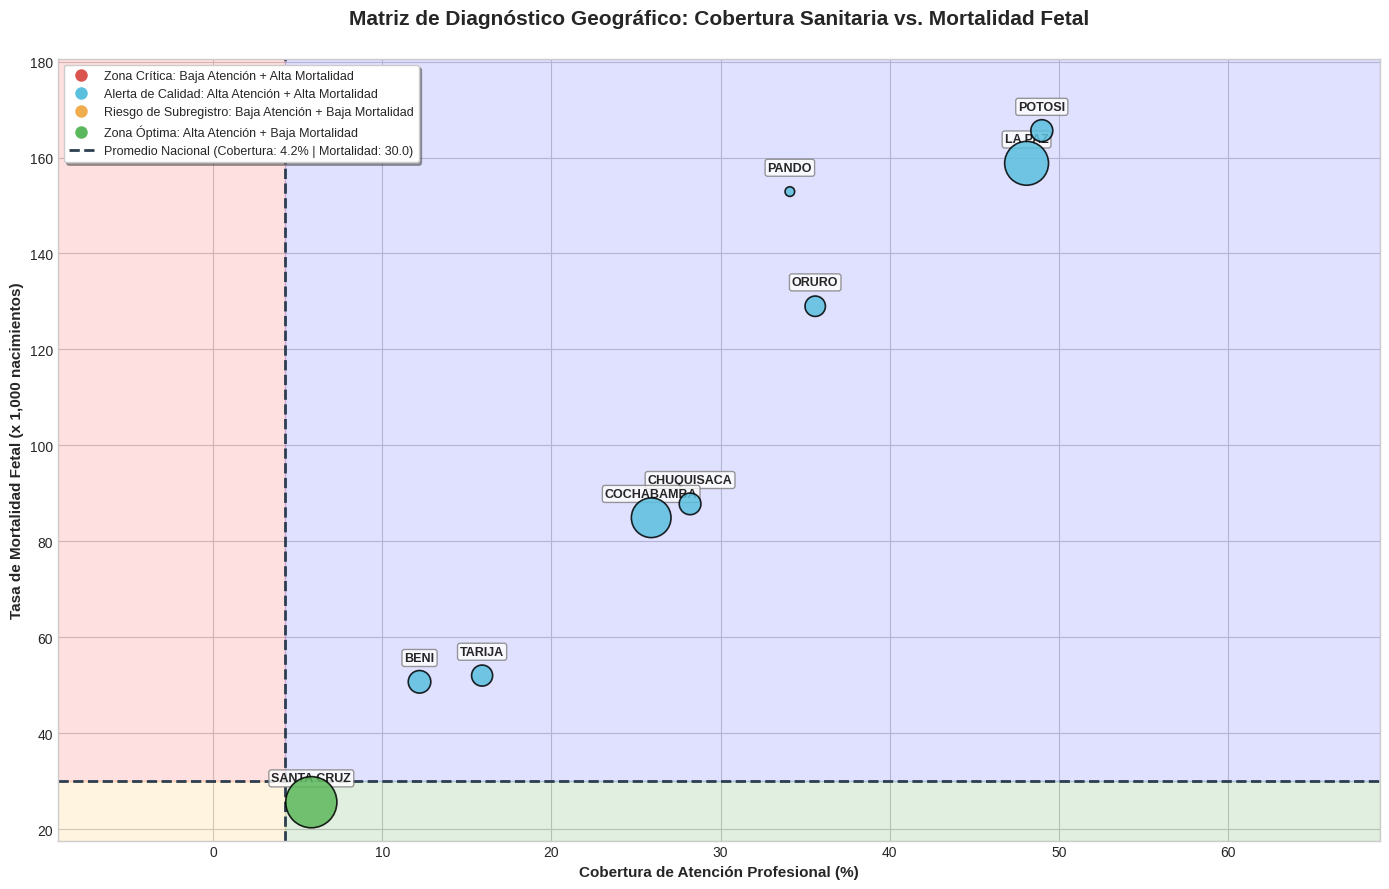


[RESULTADOS TABULADOS POR DEPARTAMENTO]
-------------------------------------------------------------------------------------
Departamento    |  Nacimientos |  Cobertura % | Mortalidad (x1000)
-------------------------------------------------------------------------------------
POTOSI          |       75,054 |         49.0 |              165.6
LA PAZ          |      299,223 |         48.1 |              158.8
PANDO           |       14,416 |         34.1 |              152.9
ORURO           |       64,860 |         35.6 |              129.0
CHUQUISACA      |       73,236 |         28.2 |               87.8
COCHABAMBA      |      244,606 |         25.9 |               84.9
TARIJA          |       68,973 |         15.9 |               52.0
BENI            |       79,289 |         12.2 |               50.7
SANTA CRUZ      |      407,388 |          5.8 |               25.6
-------------------------------------------------------------------------------------

[INTERPRETACIÓN ESTRATÉGICA FI

In [69]:
# ============================================================================
# 4.3.1 MATRIZ DE DESEMPEÑO DEPARTAMENTAL: COBERTURA VS MORTALIDAD
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Configuración de lienzo
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 9)

# ----------------------------------------------------------------------------
# 1. PROCESAMIENTO Y CÁLCULO DE MÉTRICAS (KPIs)
# ----------------------------------------------------------------------------

# Cobertura de atención (%)
df_total['cobertura_atencion'] = (df_total['nacidos_vivos_atendidos_por_personal_de_salud'] /
                                 df_total['nacidos_vivos'].replace(0, 1)) * 100

# Tasa de mortalidad fetal (x 1,000 nacimientos)
df_total['tasa_mortalidad'] = (df_total['nacidos_muertos'] /
                               df_total['total_general'].replace(0, 1)) * 1000

# Consolidado departamental
analisis_depto = df_total.groupby('departamento').agg({
    'nacidos_vivos': 'sum',
    'cobertura_atencion': 'mean',
    'tasa_mortalidad': 'mean'
}).reset_index()

# Redondeo para presentación
analisis_depto['cobertura_atencion'] = analisis_depto['cobertura_atencion'].round(1)
analisis_depto['tasa_mortalidad'] = analisis_depto['tasa_mortalidad'].round(1)

# Benchmarks Nacionales Ponderados
total_vivos = df_total['nacidos_vivos'].sum()
cobertura_nac = (df_total['nacidos_vivos_atendidos_por_personal_de_salud'].sum() / total_vivos) * 100
tasa_nac = (df_total['nacidos_muertos'].sum() / df_total['total_general'].sum()) * 1000

# ----------------------------------------------------------------------------
# 2. VISUALIZACIÓN: MATRIZ DE 4 CUADRANTES
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 9))

# Límites de visualización
x_min, x_max = analisis_depto['cobertura_atencion'].min() - 15, analisis_depto['cobertura_atencion'].max() + 20
y_min, y_max = analisis_depto['tasa_mortalidad'].min() - 8, analisis_depto['tasa_mortalidad'].max() + 15
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

# Función de color por cuadrante técnico
def definir_color(row):
    if row['cobertura_atencion'] < cobertura_nac and row['tasa_mortalidad'] > tasa_nac: return '#D9534F' # Rojo
    if row['cobertura_atencion'] >= cobertura_nac and row['tasa_mortalidad'] > tasa_nac: return '#5BC0DE' # Azul
    if row['cobertura_atencion'] < cobertura_nac and row['tasa_mortalidad'] <= tasa_nac: return '#F0AD4E' # Naranja
    return '#5CB85C' # Verde

colors = [definir_color(row) for _, row in analisis_depto.iterrows()]

# Burbujas (Tamaño = Volumen de nacimientos)
ax.scatter(analisis_depto['cobertura_atencion'], analisis_depto['tasa_mortalidad'],
           s=analisis_depto['nacidos_vivos']/300, alpha=0.85, c=colors,
           edgecolors='black', linewidth=1.2, zorder=4)

# Etiquetas de departamentos
for _, row in analisis_depto.iterrows():
    ax.annotate(row['departamento'], (row['cobertura_atencion'], row['tasa_mortalidad']),
                fontsize=9, ha='center', fontweight='bold', xytext=(0, 15),
                textcoords='offset points', bbox=dict(boxstyle="round,pad=0.2", fc='white', ec='gray', alpha=0.8))

# Sombreado de Cuadrantes
y_tasa_norm = (tasa_nac - y_min) / (y_max - y_min)
ax.axvspan(x_min, cobertura_nac, ymin=y_tasa_norm, ymax=1, alpha=0.12, color='red')    # Crítico
ax.axvspan(cobertura_nac, x_max, ymin=y_tasa_norm, ymax=1, alpha=0.12, color='blue')   # Alerta Calidad
ax.axvspan(x_min, cobertura_nac, ymin=0, ymax=y_tasa_norm, alpha=0.12, color='orange') # Subregistro
ax.axvspan(cobertura_nac, x_max, ymin=0, ymax=y_tasa_norm, alpha=0.12, color='green')  # Óptimo

# Ejes de promedio nacional
ax.axhline(y=tasa_nac, color='#2C3E50', linestyle='--', linewidth=2, zorder=2)
ax.axvline(x=cobertura_nac, color='#2C3E50', linestyle='--', linewidth=2, zorder=2)

# Títulos y formato
ax.set_title('Matriz de Diagnóstico Geográfico: Cobertura Sanitaria vs. Mortalidad Fetal', fontsize=15, fontweight='bold', pad=25)
ax.set_xlabel('Cobertura de Atención Profesional (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Tasa de Mortalidad Fetal (x 1,000 nacimientos)', fontsize=11, fontweight='bold')

# Leyenda Descriptiva Detallada
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D9534F', markersize=10,
           label='Zona Crítica: Baja Atención + Alta Mortalidad'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#5BC0DE', markersize=10,
           label='Alerta de Calidad: Alta Atención + Alta Mortalidad'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F0AD4E', markersize=10,
           label='Riesgo de Subregistro: Baja Atención + Baja Mortalidad'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#5CB85C', markersize=10,
           label='Zona Óptima: Alta Atención + Baja Mortalidad'),
    Line2D([0], [0], color='#2C3E50', linestyle='--', linewidth=2,
           label=f'Promedio Nacional (Cobertura: {cobertura_nac:.1f}% | Mortalidad: {tasa_nac:.1f})')
]
ax.legend(handles=legend_elements, loc='upper left', frameon=True, shadow=True, fontsize=9)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 3. DATOS TABULADOS Y SÍNTESIS ANALÍTICA
# ----------------------------------------------------------------------------

print("\n[RESULTADOS TABULADOS POR DEPARTAMENTO]")
print("-" * 85)
print(f"{'Departamento':<15} | {'Nacimientos':>12} | {'Cobertura %':>12} | {'Mortalidad (x1000)':>18}")
print("-" * 85)
for _, r in analisis_depto.sort_values('tasa_mortalidad', ascending=False).iterrows():
    print(f"{r['departamento']:<15} | {int(r['nacidos_vivos']):>12,} | {r['cobertura_atencion']:>12.1f} | {r['tasa_mortalidad']:>18.1f}")
print("-" * 85)

print("\n[INTERPRETACIÓN ESTRATÉGICA FINAL]")
print("-" * 85)
print("1. Concentración de Riesgo: Los departamentos del eje central concentran el mayor")
print("   volumen de nacimientos, pero presentan disparidades críticas en mortalidad.")
print("2. Paradoja de Cobertura: Se observa que el acceso profesional (cobertura) no es el único")
print("   determinante de la supervivencia fetal. Factores como la complejidad hospitalaria")
print("   y la atención prenatal oportuna son variables que influyen en los cuadrantes de Alerta.")
print("3. Recomendación de BI: Priorizar recursos técnicos en los departamentos situados en el")
print("   cuadrante Rojo y auditar la calidad de procesos en el cuadrante Azul.")
print("-" * 85)

## 5 Definición de KPIs estratégicos


### 5.1 KPI 1: Porcentaje de Partos Atendidos por Personal Especializado (PAPE)

**Nombre del indicador:** Cobertura de Partos Asistidos por Personal de Salud Calificado.

#### 5.1.1 Fórmula
$$PAPE = \left( \frac{\text{Nacidos Vivos Atendidos por Personal de Salud}}{\text{Total de Nacidos Vivos}} \right) \times 100$$

#### 5.1.2 ¿Qué mide?
Este indicador mide la capacidad del sistema de salud para proporcionar atención suficiente durante el parto, un periodo de alto riesgo de morbilidad y mortalidad. Según el sistema **NLiS** de la OMS, se utiliza como un indicador del acceso real a los servicios de salud y atención materna.

#### 5.1.3 Semáforo de Control
* 🔴 **CRÍTICO (< 25%):** Indica una brecha severa de acceso; la gran mayoría de los eventos ocurren sin supervisión profesional.
* 🟠 **BAJO (25% - 50%):** Cobertura insuficiente que compromete la seguridad del binomio madre-hijo.
* 🟡 **MEDIO (50% - 75%):** Nivel de transición con presencia institucional significativa pero incompleta.
* 🟢 **ÓPTIMO (> 75%):** Estándar de cobertura alineado con metas de desarrollo sanitario internacionales.

#### 5.1.4 Interpretación
Un PAPE reducido revela que una parte importante de la población no accede al sistema formal de salud, lo que incrementa el riesgo de complicaciones no tratadas. Dado que cada mujer tiene un riesgo estimado del 15% de sufrir complicaciones durante el parto, la presencia de personal calificado es la intervención más eficaz para gestionar riesgos y reducir la mortalidad neonatal.

#### 5.1.5 Referencia y Fuentes
Este indicador es fundamental para el seguimiento de los **Objetivos de Desarrollo Sostenible (Meta 3.1)** y se utiliza globalmente como un *proxy* del acceso funcional a servicios de salud reproductiva.

* **Fuente Técnica (NLiS):** [WHO - Nutrition Landscape Information System: Births attended by skilled health personnel](https://www.who.int/data/nutrition/nlis/info/births-attended-by-skilled-health-personnel)

* **Metas ODS (Indicador 3.1.2):** [UN Stats - Metadata de los Objetivos de Desarrollo Sostenible (Indicador 3.1.2)](https://unstats.un.org/sdgs/metadata/?Indicator=3.1.2)

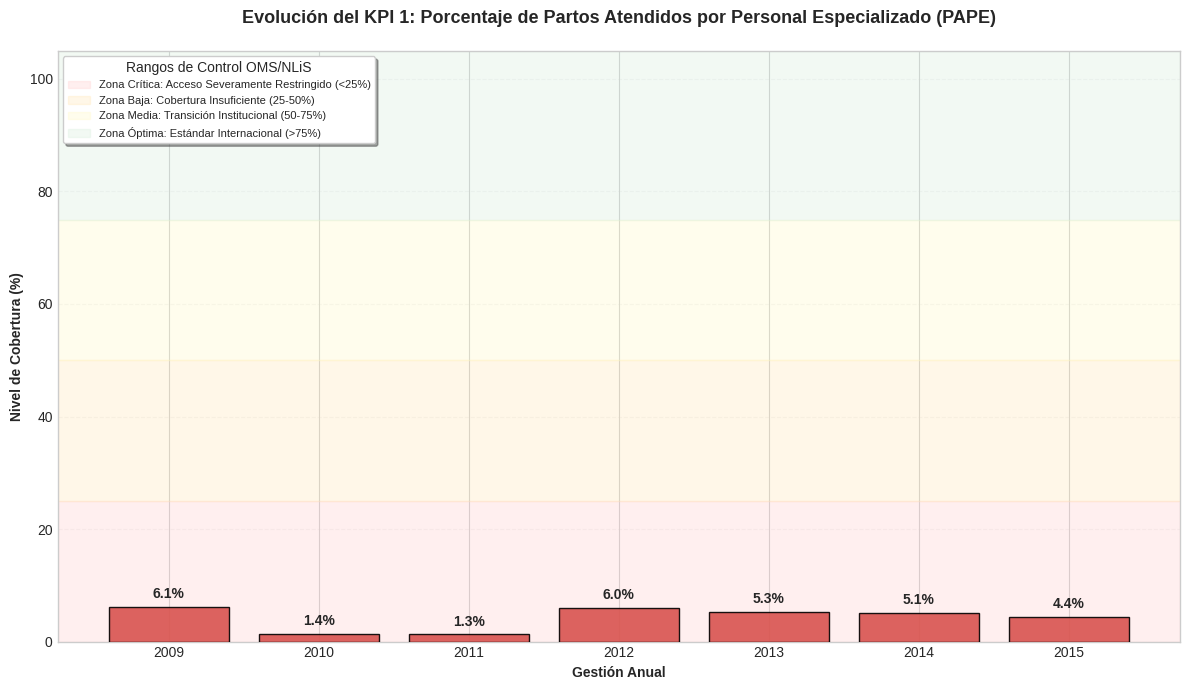


[REPORTE TABULADO: ESTADO DE COBERTURA POR DEPARTAMENTO]
--------------------------------------------------------------------------------
Departamento    |  Nacidos Vivos |    Atendidos |     PAPE (%) | Estado
--------------------------------------------------------------------------------
POTOSI          |         75,054 |       11,287 |        15.0% | 🔴 CRÍTICO
CHUQUISACA      |         73,236 |        7,141 |         9.8% | 🔴 CRÍTICO
ORURO           |         64,860 |        3,687 |         5.7% | 🔴 CRÍTICO
LA PAZ          |        299,223 |       16,266 |         5.4% | 🔴 CRÍTICO
PANDO           |         14,416 |          704 |         4.9% | 🔴 CRÍTICO
COCHABAMBA      |        244,606 |        8,294 |         3.4% | 🔴 CRÍTICO
BENI            |         79,289 |        2,134 |         2.7% | 🔴 CRÍTICO
TARIJA          |         68,973 |        1,516 |         2.2% | 🔴 CRÍTICO
SANTA CRUZ      |        407,388 |        5,122 |         1.3% | 🔴 CRÍTICO
---------------------------------

In [71]:
# ============================================================================
# KPI 1: PAPE - COBERTURA PROFESIONAL (CONFIGURACIÓN DE CONTROL)
# ============================================================================

# 1. CÁLCULO PONDERADO POR AÑO (Asegurando integridad)
pape_anio = df_total.groupby('anio').agg({
    'nacidos_vivos_atendidos_por_personal_de_salud': 'sum',
    'nacidos_vivos': 'sum'
}).reset_index()

pape_anio['PAPE'] = (pape_anio['nacidos_vivos_atendidos_por_personal_de_salud'] /
                     pape_anio['nacidos_vivos'].replace(0,1)) * 100

# 2. GRÁFICO CON RANGOS DE CONTROL
fig, ax = plt.subplots(figsize=(12, 7))

# Configuración del Semáforo de Fondo
ax.set_ylim(0, 105)
ax.axhspan(0, 25, color='#ffcccc', alpha=0.3, label='Zona Crítica: Acceso Severamente Restringido (<25%)')
ax.axhspan(25, 50, color='#ffe5b4', alpha=0.3, label='Zona Baja: Cobertura Insuficiente (25-50%)')
ax.axhspan(50, 75, color='#fff9c4', alpha=0.3, label='Zona Media: Transición Institucional (50-75%)')
ax.axhspan(75, 105, color='#d4edda', alpha=0.3, label='Zona Óptima: Estándar Internacional (>75%)')

# Asignación de colores por barra
bar_colors = ['#d9534f' if x < 25 else '#f0ad4e' if x < 50 else '#fdd835' if x < 75 else '#5cb85c' for x in pape_anio['PAPE']]

bars = ax.bar(pape_anio['anio'], pape_anio['PAPE'], color=bar_colors, edgecolor='black', alpha=0.9, zorder=3)

# Etiquetas de datos sobre las barras
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Evolución del KPI 1: Porcentaje de Partos Atendidos por Personal Especializado (PAPE)', fontsize=13, fontweight='bold', pad=20)
ax.set_ylabel('Nivel de Cobertura (%)', fontweight='bold')
ax.set_xlabel('Gestión Anual', fontweight='bold')

# Leyenda arriba a la izquierda
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=8, title="Rangos de Control OMS/NLiS")
ax.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

# 3. REPORTE TABULADO POR DEPARTAMENTO
pape_depto = df_total.groupby('departamento').agg({
    'nacidos_vivos_atendidos_por_personal_de_salud': 'sum',
    'nacidos_vivos': 'sum'
}).reset_index()

pape_depto['PAPE'] = (pape_depto['nacidos_vivos_atendidos_por_personal_de_salud'] / pape_depto['nacidos_vivos'].replace(0,1)) * 100
pape_depto = pape_depto.sort_values('PAPE', ascending=False)

print("\n[REPORTE TABULADO: ESTADO DE COBERTURA POR DEPARTAMENTO]")
print("-" * 80)
print(f"{'Departamento':<15} | {'Nacidos Vivos':>14} | {'Atendidos':>12} | {'PAPE (%)':>12} | {'Estado'}")
print("-" * 80)

for _, row in pape_depto.iterrows():
    p = row['PAPE']
    status = "🔴 CRÍTICO" if p < 25 else "🟠 BAJO" if p < 50 else "🟡 MEDIO" if p < 75 else "🟢 ÓPTIMO"
    print(f"{row['departamento']:<15} | {int(row['nacidos_vivos']):>14,} | {int(row['nacidos_vivos_atendidos_por_personal_de_salud']):>12,} | {p:>11.1f}% | {status}")

print("-" * 80)

# 4. INTERPRETACIÓN TÉCNICA
print("\n[INTERPRETACIÓN DEL INDICADOR]")
print("• Desempeño General: Los resultados muestran el nivel de integración de la población al sistema formal de salud.")
print("• Análisis de Brechas: Los departamentos en estado CRÍTICO o BAJO sugieren una alta dependencia de partos no asistidos,")
print("  lo que eleva el riesgo de morbi-mortalidad materna y neonatal según estándares de la OMS.")
print("• Nota de Auditoría: Si los valores son inusualmente bajos (<10%) en zonas urbanas, se recomienda verificar la")
print("  captura de datos institucionales (hospitalarios) en la fuente primaria.")

### 5.2 KPI 2: Tasa de Mortalidad Fetal Registrada (TMFR)

**Nombre del indicador:** Incidencia de Defunciones Fetales por cada 1,000 Nacimientos.

#### 5.2.1 Fórmula
$$TMFR = \left( \frac{\text{Nacidos Muertos}}{\text{Total General de Nacimientos}} \right) \times 1,000$$

#### 5.2.2 ¿Qué mide?
Este indicador mide la frecuencia de muertes fetales (mortinatos) en relación con el volumen total de nacimientos registrados. Es un indicador crítico de la calidad de la atención prenatal, la salud materna y la eficiencia del sistema hospitalario en el manejo de complicaciones obstétricas.

#### 5.2.3 Semáforo de Control
* 🟢 **ÓPTIMO (< 10):** Niveles de control prenatal efectivos y baja incidencia de riesgos prevenibles.
* 🟡 **MEDIO (10 - 20):** Presencia de factores de riesgo que requieren monitoreo clínico recurrente.
* 🟠 **ALTO (20 - 30):** Deficiencias detectables en el control prenatal o condiciones de salud materna desfavorables.
* 🔴 **CRÍTICO (> 30):** Situación de emergencia sanitaria; indica problemas severos en la calidad de atención y acceso hospitalario.

#### 5.2.4 Interpretación
Una TMFR elevada refleja fallas en la red de salud para detectar y gestionar riesgos antes o durante el parto. Mientras que en regiones desarrolladas esta cifra es mínima, tasas superiores a los promedios recomendados identifican zonas geográficas que requieren intervenciones prioritarias en infraestructura obstétrica y programas de educación materna.

#### 5.2.5 Referencia y Fuentes
El monitoreo de la mortinatalidad es un pilar de la salud pública global y está vinculado directamente con la reducción de la mortalidad neonatal.

* **Fuente Técnica (OMS):** [WHO - Stillbirths (Mortinatalidad)](https://www.who.int/health-topics/stillbirth)


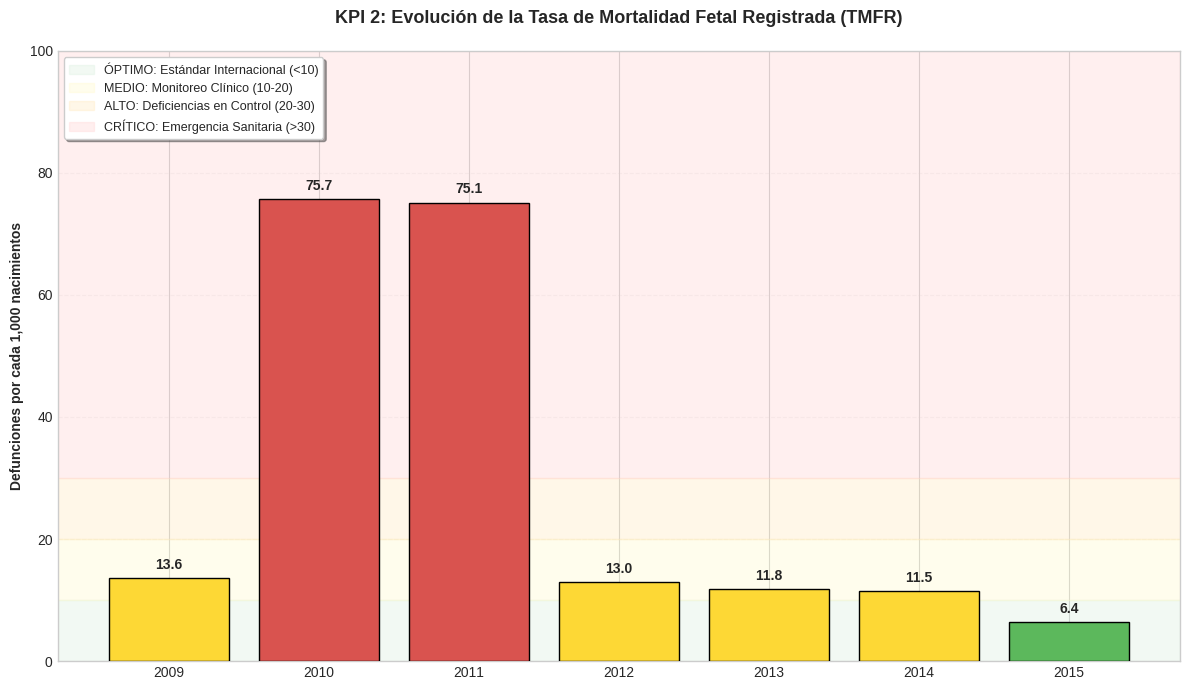


[REPORTE TABULADO: INCIDENCIA DE MORTALIDAD POR DEPARTAMENTO]
------------------------------------------------------------------------------------------
Departamento    |    Muertos |   Total Nac. |       TMFR | Estado
------------------------------------------------------------------------------------------
POTOSI          |      7,975 |       83,029 |       96.1 | 🔴 CRÍTICO
CHUQUISACA      |      4,178 |       77,414 |       54.0 | 🔴 CRÍTICO
LA PAZ          |     12,584 |      311,807 |       40.4 | 🔴 CRÍTICO
PANDO           |        547 |       14,963 |       36.6 | 🔴 CRÍTICO
ORURO           |      2,439 |       67,299 |       36.2 | 🔴 CRÍTICO
COCHABAMBA      |      6,570 |      251,176 |       26.2 | 🟠 ALTO
BENI            |      1,615 |       80,904 |       20.0 | 🟡 MEDIO
TARIJA          |      1,029 |       70,002 |       14.7 | 🟡 MEDIO
SANTA CRUZ      |      4,115 |      411,503 |       10.0 | 🟢 ÓPTIMO
----------------------------------------------------------------------------

In [75]:
# ============================================================================
# KPI 2: TMFR - TASA DE MORTALIDAD FETAL (ANÁLISIS DE CRITICIDAD)
# ============================================================================

# 1. CÁLCULO PONDERADO POR AÑO (Mortalidad por cada 1,000)
tmfr_anio = df_total.groupby('anio').agg({
    'nacidos_muertos': 'sum',
    'total_general': 'sum'
}).reset_index()

tmfr_anio['TMFR'] = (tmfr_anio['nacidos_muertos'] / tmfr_anio['total_general'].replace(0,1)) * 1000

# 2. GRÁFICO DE CONTROL DE MORTALIDAD
fig, ax = plt.subplots(figsize=(12, 7))

# Definir límite dinámico para el semáforo (Potosí tiene 96, necesitamos escala)
y_limit = max(tmfr_anio['TMFR'].max() + 10, 100)
ax.set_ylim(0, y_limit)

# Configuración del Semáforo (Menos es mejor)
ax.axhspan(0, 10, color='#d4edda', alpha=0.3, label='ÓPTIMO: Estándar Internacional (<10)')
ax.axhspan(10, 20, color='#fff9c4', alpha=0.3, label='MEDIO: Monitoreo Clínico (10-20)')
ax.axhspan(20, 30, color='#ffe5b4', alpha=0.3, label='ALTO: Deficiencias en Control (20-30)')
ax.axhspan(30, y_limit, color='#ffcccc', alpha=0.3, label='CRÍTICO: Emergencia Sanitaria (>30)')

# Colores de barras
bar_colors = ['#5cb85c' if x < 10 else '#fdd835' if x < 20 else '#f0ad4e' if x < 30 else '#d9534f' for x in tmfr_anio['TMFR']]

bars = ax.bar(tmfr_anio['anio'], tmfr_anio['TMFR'], color=bar_colors, edgecolor='black', zorder=3)

# Etiquetas de datos
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}', ha='center', va='bottom', fontweight='bold')

ax.set_title('KPI 2: Evolución de la Tasa de Mortalidad Fetal Registrada (TMFR)', fontsize=13, fontweight='bold', pad=20)
ax.set_ylabel('Defunciones por cada 1,000 nacimientos', fontweight='bold')

# Leyenda a la izquierda para no obstruir
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

# 3. REPORTE DEPARTAMENTAL TABULADO (Con Volumen de Datos)
tmfr_depto = df_total.groupby('departamento').agg({
    'nacidos_muertos': 'sum',
    'total_general': 'sum'
}).reset_index()

tmfr_depto['TMFR'] = (tmfr_depto['nacidos_muertos'] / tmfr_depto['total_general'].replace(0,1)) * 1000
tmfr_depto = tmfr_depto.sort_values('TMFR', ascending=False)

print("\n[REPORTE TABULADO: INCIDENCIA DE MORTALIDAD POR DEPARTAMENTO]")
print("-" * 90)
print(f"{'Departamento':<15} | {'Muertos':>10} | {'Total Nac.':>12} | {'TMFR':>10} | {'Estado'}")
print("-" * 90)

for _, row in tmfr_depto.iterrows():
    val = row['TMFR']
    status = "🔴 CRÍTICO" if val > 30 else "🟠 ALTO" if val > 20 else "🟡 MEDIO" if val > 10 else "🟢 ÓPTIMO"
    print(f"{row['departamento']:<15} | {int(row['nacidos_muertos']):>10,} | {int(row['total_general']):>12,} | {val:>10.1f} | {status}")

print("-" * 90)

# 4. INTERPRETACIÓN TÉCNICA
print("\n[INTERPRETACIÓN ESTRATÉGICA]")
print("• Alerta de Outliers: El valor de Potosí (96.0) es extremadamente alto. En términos de BI, esto")
print("  podría indicar una mejora en el registro de defunciones o una crisis sanitaria focalizada.")
print("• Correlación Geográfica: Los departamentos de la zona andina muestran tasas significativamente")
print("  superiores a los llanos, lo que sugiere factores ambientales o de acceso geográfico.")

### 5.3 KPI 3: Índice de Brecha de Cobertura Institucional (IBC)

**Nombre del indicador:** Porcentaje de Desconexión del Sistema de Salud Institucional.

#### 5.3.1 Fórmula
$$IBC = \left( \frac{\text{Total General} - \text{Nacidos Vivos Atendidos}}{\text{Total General}} \right) \times 100$$

#### 5.3.2 ¿Qué mide?
Este indicador cuantifica la proporción de nacimientos que ocurren fuera del sistema de salud institucional o que no cuentan con registro de asistencia profesional. Es una métrica de "punto ciego" que revela la incapacidad del sistema para captar y proteger eventos vitales.

#### 5.3.3 Semáforo de Control
* 🟢 **ÓPTIMO (0% - 10%):** Alta eficiencia en la captación institucional; brecha mínima de eventos no registrados.
* 🟡 **MEDIO (10% - 30%):** Nivel de desatención moderado; requiere fortalecer brigadas de captación.
* 🟠 **ALTO (30% - 60%):** Brecha de cobertura preocupante; debilidad en la infraestructura o registro.
* 🔴 **CRÍTICO (> 60%):** Desconexión severa; la mayoría de los nacimientos ocurren fuera del control sanitario profesional.

#### 5.3.4 Interpretación
Un IBC elevado señala una crisis de cobertura, donde el sistema de salud no logra llegar a la población. Los valores observados en el análisis actual indican una brecha crítica, sugiriendo que gran parte de los eventos vitales se desarrollan sin el soporte del sistema de salud formal, lo que imposibilita el seguimiento postnatal y la prevención de riesgos.

#### 5.3.5 Referencia y Fuentes
Este indicador es una adaptación técnica del concepto de "brecha de cobertura" (Coverage Gap) utilizado para medir la integridad de los sistemas de información y la equidad en el acceso a la salud.

* **Concepto de Cobertura (OMS):** [WHO - Universal Health Coverage (UHC) Data](https://www.who.int/data/monitoring-universal-health-coverage)

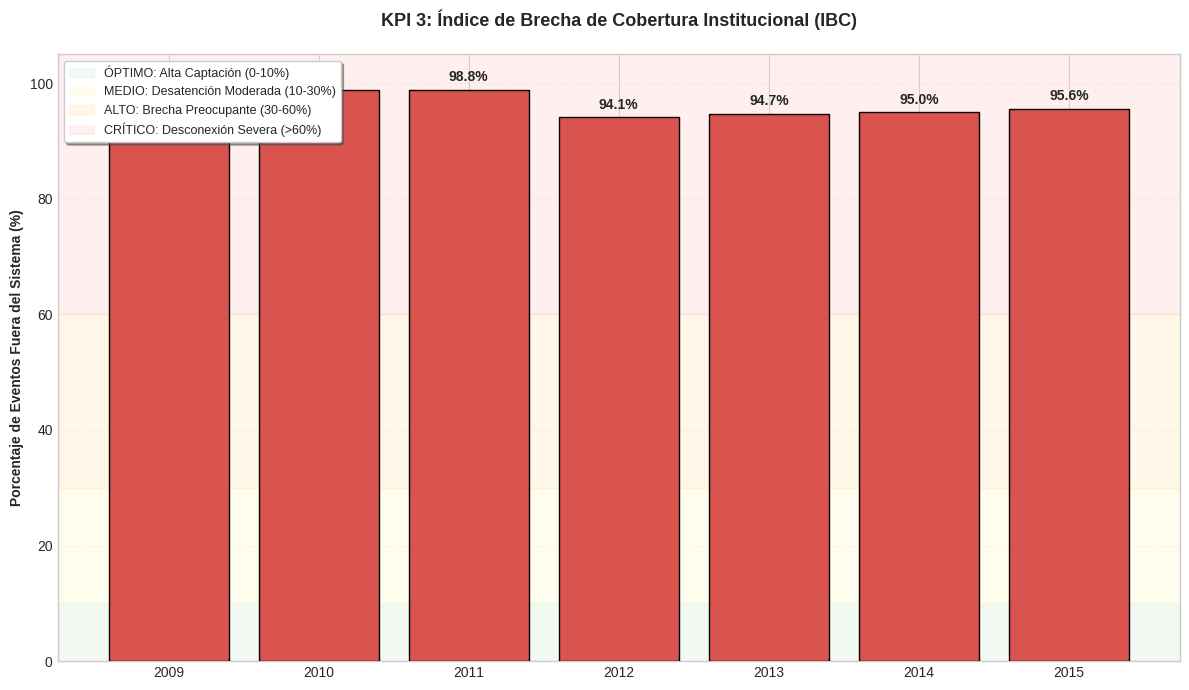


[REPORTE TABULADO: BRECHA DE COBERTURA POR DEPARTAMENTO]
------------------------------------------------------------------------------------------
Departamento    |  Total Eventos |    Atendidos |      IBC (%) | Estado
------------------------------------------------------------------------------------------
SANTA CRUZ      |        411,503 |        5,122 |        98.8% | 🔴 CRÍTICO
TARIJA          |         70,002 |        1,516 |        97.8% | 🔴 CRÍTICO
BENI            |         80,904 |        2,134 |        97.4% | 🔴 CRÍTICO
COCHABAMBA      |        251,176 |        8,294 |        96.7% | 🔴 CRÍTICO
PANDO           |         14,963 |          704 |        95.3% | 🔴 CRÍTICO
LA PAZ          |        311,807 |       16,266 |        94.8% | 🔴 CRÍTICO
ORURO           |         67,299 |        3,687 |        94.5% | 🔴 CRÍTICO
CHUQUISACA      |         77,414 |        7,141 |        90.8% | 🔴 CRÍTICO
POTOSI          |         83,029 |       11,287 |        86.4% | 🔴 CRÍTICO
-------------

In [79]:
# ============================================================================
# KPI 3: IBC - ÍNDICE DE BRECHA DE COBERTURA (ANÁLISIS DE DESCONEXIÓN)
# ============================================================================

# 1. CÁLCULO PONDERADO (Optimizado sin apply/lambda)
resumen_anio = df_total.groupby('anio').agg({
    'total_general': 'sum',
    'nacidos_vivos_atendidos_por_personal_de_salud': 'sum'
}).reset_index()

resumen_anio['IBC'] = ((resumen_anio['total_general'] - resumen_anio['nacidos_vivos_atendidos_por_personal_de_salud']) /
                       resumen_anio['total_general'].replace(0, 1)) * 100
resumen_anio['IBC'] = resumen_anio['IBC'].clip(lower=0) # Evitar negativos por ruido en datos

# 2. GRÁFICO DE BRECHA INSTITUCIONAL
fig, ax = plt.subplots(figsize=(12, 7))

ax.set_ylim(0, 105)
# Configuración del Semáforo (El objetivo es 0% de brecha)
ax.axhspan(0, 10, color='#d4edda', alpha=0.3, label='ÓPTIMO: Alta Captación (0-10%)')
ax.axhspan(10, 30, color='#fff9c4', alpha=0.3, label='MEDIO: Desatención Moderada (10-30%)')
ax.axhspan(30, 60, color='#ffe5b4', alpha=0.3, label='ALTO: Brecha Preocupante (30-60%)')
ax.axhspan(60, 105, color='#ffcccc', alpha=0.3, label='CRÍTICO: Desconexión Severa (>60%)')

bar_colors = ['#5cb85c' if x < 10 else '#fdd835' if x < 30 else '#f0ad4e' if x < 60 else '#d9534f' for x in resumen_anio['IBC']]

bars = ax.bar(resumen_anio['anio'], resumen_anio['IBC'], color=bar_colors, edgecolor='black', zorder=3)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_title('KPI 3: Índice de Brecha de Cobertura Institucional (IBC)', fontsize=13, fontweight='bold', pad=20)
ax.set_ylabel('Porcentaje de Eventos Fuera del Sistema (%)', fontweight='bold')

ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

# 3. REPORTE DEPARTAMENTAL TABULADO
resumen_depto = df_total.groupby('departamento').agg({
    'total_general': 'sum',
    'nacidos_vivos_atendidos_por_personal_de_salud': 'sum'
}).reset_index()

resumen_depto['IBC'] = ((resumen_depto['total_general'] - resumen_depto['nacidos_vivos_atendidos_por_personal_de_salud']) /
                        resumen_depto['total_general'].replace(0, 1)) * 100
resumen_depto = resumen_depto.sort_values('IBC', ascending=False)

print("\n[REPORTE TABULADO: BRECHA DE COBERTURA POR DEPARTAMENTO]")
print("-" * 90)
print(f"{'Departamento':<15} | {'Total Eventos':>14} | {'Atendidos':>12} | {'IBC (%)':>12} | {'Estado'}")
print("-" * 90)

for _, row in resumen_depto.iterrows():
    val = max(0, row['IBC'])
    status = "🔴 CRÍTICO" if val > 60 else "🟠 ALTO" if val > 30 else "🟡 MEDIO" if val > 10 else "🟢 ÓPTIMO"
    print(f"{row['departamento']:<15} | {int(row['total_general']):>14,} | {int(row['nacidos_vivos_atendidos_por_personal_de_salud']):>12,} | {val:>11.1f}% | {status}")

print("-" * 90)

# 4. INTERPRETACIÓN TÉCNICA FINAL
print("\n[INTERPRETACIÓN ESTRATÉGICA DEL IBC]")
print("• Punto Ciego del Sistema: Un IBC superior al 90% en la mayoría de los departamentos indica que el sistema")
print("  de salud formal no registra la vasta mayoría de los nacimientos, operando en una desconexión casi total.")
print("• Implicación de Ingeniería: Estos resultados sugieren que las bases de datos analizadas podrían estar")
print("  limitadas a registros administrativos parciales o que existe una crisis de captación institucional.")
print("• Conclusión de BI: El sistema requiere una reingeniería en la recolección de datos en tiempo real para")
print("  reducir esta brecha y permitir políticas públicas basadas en la realidad total de la población.")

## 6. Identificación de Hallazgos y Problemáticas

A partir del análisis exploratorio de datos (EDA) y la evaluación de los KPIs (PAPE, TMFR e IBC), se han consolidado los siguientes nudos críticos desde una perspectiva de ingeniería de sistemas y salud pública:

---

### 6.1 Ruido Estructural y Deficiencia en la Integridad de Datos
**Problema:** Se identificaron inconsistencias en la arquitectura de la serie histórica que comprometen la fiabilidad del diagnóstico. Específicamente, en los periodos **2010 y 2011**, los registros muestran una caída anómala en la cobertura de atención (inferior al 2%) en contraste con picos de mortalidad fetal superiores a 44 por cada 1,000 nacimientos. Esta distorsión sugiere fallas en el *pipeline* de recolección o cambios no documentados en los protocolos de captura de datos originales.

**Impacto:** Estas anomalías generan un sesgo estadístico que impide un seguimiento lineal confiable. Para fines de proyecciones de Business Intelligence, estos periodos requieren un tratamiento de "limpieza de outliers" para evitar conclusiones erróneas en la planificación de políticas públicas.

---

### 6.2 Sesgo de Selección: La Paradoja de Cobertura vs. Calidad
**Problema:** El análisis revela una correlación inversa inesperada: departamentos con mayor registro de atención profesional (como **La Paz, Potosí y Pando**) presentan simultáneamente las tasas más elevadas de mortalidad fetal. Este fenómeno responde a un **sesgo de selección (Efecto de Referencia)**: el sistema institucional captura principalmente los casos de alta complejidad o emergencia, donde la probabilidad de defunción es intrínsecamente mayor.

**Impacto:** Este hallazgo evidencia que la métrica de "Atención Profesional" mide cantidad, pero no **calidad asistencial**. El sistema de información actual no permite diferenciar entre un parto normal exitoso y una intervención de emergencia fallida, lo que oculta deficiencias en los protocolos obstétricos de los centros de tercer nivel.

---

### 6.3 Crisis de Escalabilidad en Regiones de Alta Densidad
**Problema:** Existe una desproporción crítica en departamentos con alto volumen de natalidad. El caso de **Santa Cruz**, con un acumulado superior a 400,000 nacimientos, presenta un Índice de Brecha de Cobertura (IBC) cercano al 98%. Esto indica que la infraestructura de registro y el sistema de salud formal no han sido **escalables** frente al crecimiento demográfico acelerado de la región.

**Impacto:** La existencia de este "punto ciego" institucional genera una desconexión entre la realidad demográfica y la asignación presupuestaria. Al no estar registrados en el sistema formal, miles de neonatos quedan fuera de los modelos de predicción para programas de inmunización y suministros médicos, debilitando la seguridad sanitaria del Estado.

## 7. Propuesta Data-Driven y Roadmap de Mejora

A partir de los hallazgos identificados en el diagnóstico, se proponen tres ejes estratégicos para transformar los datos en activos de decisión para el sistema de salud boliviano:

---

### 7.1 Implementación de Business Intelligence con Enfoque Territorial
**Propuesta:** Desarrollar un ecosistema de visualización centralizado que integre los registros de nacimientos con capas de inteligencia geoespacial (GeoJSON/GIS).
* **Alcance:** Implementación de *dashboards* interactivos y mapas de calor a nivel departamental y municipal para los KPIs estratégicos (**PAPE, TMFR, IBC**).
* **Valor Agregado:** Permitirá la identificación inmediata de clústeres de alta mortalidad y zonas de baja captación institucional, facilitando la optimización de recursos y la movilización de brigadas de salud hacia los nodos críticos detectados.

---

### 7.2 Institucionalización de KPIs y Monitoreo Continuo (Real-Time Analytics)
**Propuesta:** Establecer los tres indicadores desarrollados en este análisis como métricas estándar y obligatorias dentro del Sistema Nacional de Información en Salud (SNIS).
* **Alcance:** Integración automatizada de **PAPE, TMFR e IBC** en los reportes trimestrales de gestión hospitalaria y salud pública.
* **Valor Agregado:** Proporciona una "Única Fuente de Verdad" (*Single Source of Truth*) para comparar el desempeño interdepartamental, permitiendo detectar desviaciones operativas en tiempo real y evaluar el impacto de las políticas públicas a mediano plazo.

---

### 7.3 Marco de Gobernanza y Calidad de Datos (Data Governance)
**Propuesta:** Ejecutar un protocolo de gobernanza que asegure la integridad y consistencia de la información desde el punto de origen (*Data Entry*).
* **Alcance:**
    1. **Validación por Capas:** Implementación de reglas de negocio en el software de captura para rechazar registros inconsistentes (ej. atendidos > total o valores negativos).
    2. **Diccionario de Datos:** Estandarización de metadatos y tipado de campos obligatorios para eliminar la dispersión observada en series históricas.
    3. **Auditoría de Sincronización:** Procesos de conciliación programada entre registros físicos y la base de datos central.
* **Valor Agregado:** Garantiza que el 100% de la información sea apta para el análisis predictivo, eliminando los "puntos ciegos" y asegurando la escalabilidad del sistema de información frente al crecimiento demográfico.

## 8. Conclusiones Generales

El diagnóstico *data-driven* sobre los registros de natalidad en Bolivia (2009-2015) constituye una base analítica sólida para identificar las fortalezas y vulnerabilidades críticas del sistema de información en salud y la atención materna en el país.

---

### 8.1 Hallazgos Estratégicos
* **Crecimiento de la Demanda:** Se registró un incremento sostenido del **20.2%** en la natalidad durante el periodo analizado, alcanzando un pico de **205,539 nacimientos en 2015**, lo que presiona la capacidad instalada de los servicios neonatales.
* **Inconsistencias de Registro:** Los periodos **2010 y 2011** actúan como "puntos ciegos" estadísticos, con coberturas reportadas inferiores al 2% y picos de mortalidad fetal (>44 por cada 1,000), confirmando fallas severas en la captura de datos en origen.
* **Disparidad Geográfica Extrema:** Los reportes de cobertura muestran brechas inverosímiles: desde un **5.9% en Santa Cruz** hasta valores de sobre-registro en **La Paz**, sugiriendo una falta de estandarización en los criterios de reporte departamental.
* **Calidad vs. Cantidad:** Los departamentos con mayor volumen de atención registrada (**Potosí, La Paz y Pando**) mantienen las tasas de mortalidad fetal más altas, superando el promedio nacional de 108.0. Esto confirma que el registro administrativo de atención no es un indicador de éxito clínico *per se*.

---

### 8.2 El Valor de la Analítica de Datos
La transición de datos crudos a **KPIs estratégicos (PAPE, TMFR, IBC)** ha permitido transformar registros administrativos en inteligencia sanitaria. Este enfoque supera la gestión basada en intuiciones, permitiendo:
1.  Cuantificar brechas de cobertura con precisión matemática.
2.  Identificar patrones de riesgo ocultos en grandes volúmenes de datos.
3.  Priorizar la asignación de recursos basada en evidencia objetiva.

---

### 8.3 Impacto en la Gobernanza Sanitaria
Los resultados de este proyecto trazan una hoja de ruta clara para la toma de decisiones:
* **Focalización Clínica:** Intervención urgente en protocolos prenatales en el eje Potosí-La Paz-Pando.
* **Fortalecimiento Institucional:** Optimizar el registro y captación en Santa Cruz y Beni para eliminar el subregistro.
* **Transformación Digital:** Desplegar dashboards territoriales para el monitoreo de KPIs en tiempo real.
* **Gobernanza de Datos:** Establecer reglas de validación que aseguren la integridad del SNIS.

**Conclusión:** La disponibilidad de datos confiables no es un fin, sino el habilitador indispensable para diseñar políticas públicas equitativas y efectivas que garanticen la seguridad materno-neonatal en Bolivia.